## Salary Analysis


In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import ast
from datasets import load_dataset

# Loading Data
# Load the job postings dataset directly from Hugging Face
ds = load_dataset("lukebarousse/data_jobs")
# Convert training split to a pandas DataFrame
df=ds['train'].to_pandas()


# Data Cleanup
# Parse job_posted_date as datetime to enable time-based operations
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# job_skills is stored as a stringified list — convert back to an actual Python list
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [2]:
# Define the Middle East country list used to scope the analysis
middle_east=['Algeria', 'Bahrain', 'Egypt', 'Iraq', 'Jordan', 'Kuwait', 'Lebanon', 'Libya', 'Morocco', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia', 'Tunisia', 'Turkey', 'United Arab Emirates','Yemen']

# Filter to Middle East jobs only
df_me=df[df['job_country'].isin(middle_east)]
df_me.info()


<class 'pandas.DataFrame'>
Index: 21481 entries, 83 to 785686
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        21481 non-null  str           
 1   job_title              21481 non-null  str           
 2   job_location           21481 non-null  str           
 3   job_via                21481 non-null  str           
 4   job_schedule_type      21398 non-null  str           
 5   job_work_from_home     21481 non-null  bool          
 6   search_location        21481 non-null  str           
 7   job_posted_date        21481 non-null  datetime64[us]
 8   job_no_degree_mention  21481 non-null  bool          
 9   job_health_insurance   21481 non-null  bool          
 10  job_country            21481 non-null  str           
 11  salary_rate            101 non-null    str           
 12  salary_year_avg        87 non-null     float64       
 13  salary_hour_avg

In [3]:
# Keep only rows that have salary data — required for all salary-related analysis
df_salary = df_me[df_me['salary_year_avg'].notna()]


In [4]:
# Check what proportion of salary records each country contributes
# Helps assess data balance before drawing comparisons between countries
df_salary['job_country'].value_counts(normalize=True) * 100


job_country
United Arab Emirates    25.287356
Turkey                  24.137931
Egypt                   22.988506
Morocco                 14.942529
Tunisia                  5.747126
Jordan                   2.298851
Algeria                  2.298851
Lebanon                  2.298851
Name: proportion, dtype: float64

C:\Users\tmara\AppData\Local\Temp\ipykernel_9296\3244067822.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


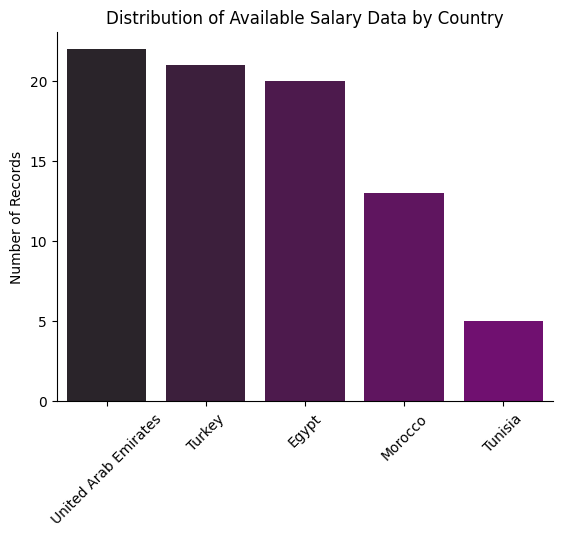

In [5]:
# Identify the top 5 countries by number of available salary records
top_countries = df_salary['job_country'].value_counts().head(5).index

# Filter to those top 5 countries only
df_top = df_salary[df_salary['job_country'].isin(top_countries)]

# Visualize how salary records are distributed across the top countries
sns.countplot(
    data=df_top,
    x='job_country',
    order=top_countries,
    palette='dark:purple'
)

plt.title('Distribution of Available Salary Data by Country')
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('Number of Records')

sns.despine()
plt.show()


### The salary data is relatively balanced across the United Arab Emirates, Turkey, and Egypt, each contributing a comparable share of records. Therefore, the analysis will focus on these countries to provide more reliable comparative insights.


--------------------------------------------------------------------

## Salary Analysis

Note: The salary data is limited (87 of 2148 entries), but relatively balanced across the United Arab Emirates, Turkey, and Egypt, each contributing a comparable share of records. Therefore, the analysis will focus on these countries to provide more reliable comparative insights.


------------------------------------------------------------------

In [6]:
# Select the top 3 countries (UAE, Turkey, Egypt) based on salary record count
Top3_countries =top_countries[0:3]


In [ ]:
# Filter the Middle East dataset to only the top 3 countries
df_top3_countries = df_me[df_me['job_country'].isin(Top3_countries)]

# Drop rows without salary data — required for the boxplot
df_top3_countries = df_top3_countries.dropna(subset=['salary_year_avg'])


In [8]:
# Compute the median salary per country and sort descending
# This order will be used to display countries from highest to lowest median salary in the chart
order=df_top3_countries.groupby('job_country')['salary_year_avg'].median().sort_values(ascending=False)



C:\Users\tmara\AppData\Local\Temp\ipykernel_9296\2326470825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\tmara\AppData\Local\Temp\ipykernel_9296\2326470825.py:4: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


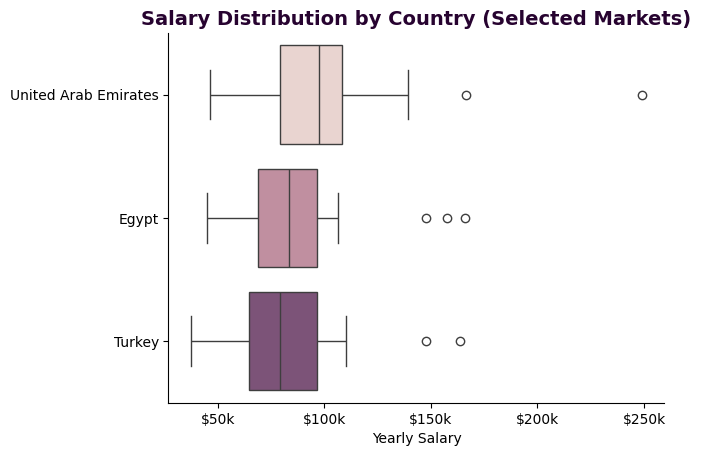

In [9]:
plt.Figure(figsize=(8,5))

# Boxplot shows the full salary distribution (median, IQR, outliers) per country
sns.boxplot(
    df_top3_countries,
    x='salary_year_avg',
    y='job_country',
    order=order.index,
    palette=sns.cubehelix_palette(n_colors=4)
    )

plt.title('Salary Distribution by Country (Selected Markets)', fontsize=14, weight='bold',color ="#270330")
plt.xlabel('Yearly Salary')
plt.ylabel('')

# Format x-axis as readable dollar values (e.g., 100000 → $100k)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))


sns.despine()
plt.show()


## Salary Distribution by Country (Selected Markets)

The salary distribution across the United Arab Emirates, Egypt, and Turkey reveals noticeable differences in both salary levels and variability.

Overall, the United Arab Emirates offers higher salary ranges compared to Egypt and Turkey, indicating a stronger compensation market. Egypt and Turkey show relatively similar distributions, though with slightly lower median salaries.

Additionally, the presence of several high-value outliers across all countries suggests that while most salaries fall within a moderate range, there are opportunities for significantly higher compensation in certain roles or companies.


--------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------

In [10]:
Top3_countries


Index(['United Arab Emirates', 'Turkey', 'Egypt'], dtype='str', name='job_country')

In [11]:
# Summary statistics per role — helps understand sample sizes and spread before plotting
df_top3_countries.groupby('job_title_short')['salary_year_avg'].describe()


,count,mean,std,min,25%,50%,75%,max
job_title_short,,,,,,,,
Data Analyst,14.0,80937.214286,32527.760518,50400.0,57500.0,73775.0,98500.00,163782.0
Data Engineer,16.0,106549.656250,47246.553990,45000.0,79200.0,96773.0,108516.25,249000.0
Data Scientist,11.0,94168.636364,36797.702222,47370.0,71000.0,88128.0,98554.75,166419.5
Machine Learning Engineer,4.0,90925.000000,51979.058283,46500.0,65625.0,75600.0,100900.00,166000.0
Senior Data Analyst,5.0,103970.000000,6627.721139,98500.0,98500.0,100500.0,111175.00,111175.0
Senior Data Engineer,1.0,96773.000000,NaN,96773.0,96773.0,96773.0,96773.00,96773.0
Senior Data Scientist,8.0,78365.750000,10364.578990,64800.0,70200.0,79200.0,88128.00,90670.0
Software Engineer,4.0,67250.000000,21938.778453,37500.0,57975.0,72000.0,81275.00,87500.0


---------------------------------------------------------------------------------------------------------------------------------
## Salary Distribution Across Key Data Roles


##### Due to the limited number of salary records per role, the following analysis provides indicative comparisons rather than definitive conclusions.


C:\Users\tmara\AppData\Local\Temp\ipykernel_9296\962385783.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\tmara\AppData\Local\Temp\ipykernel_9296\962385783.py:8: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(


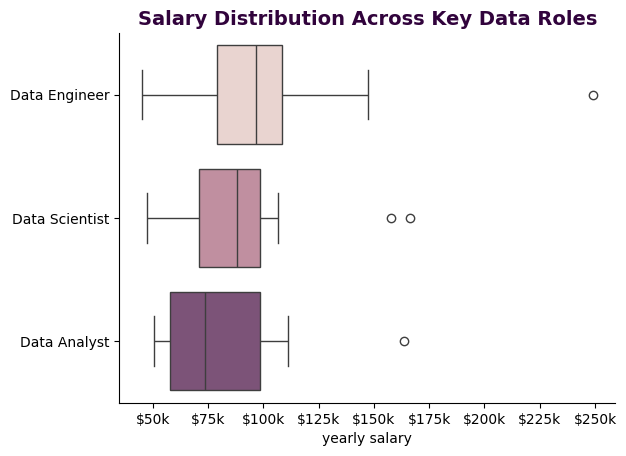

In [12]:
# Focus on the three most relevant roles for this comparison
roles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_roles_salary = df_top3_countries[df_top3_countries['job_title_short'].isin(roles)]

# Sort roles by median salary so the highest-paying role appears at the top of the chart
order_salary=df_roles_salary.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False)

sns.boxplot(
    data = df_roles_salary,
    x ='salary_year_avg',
    y ='job_title_short',
    order = order_salary.index,
    palette=sns.cubehelix_palette(n_colors=4)
)
plt.title('Salary Distribution Across Key Data Roles', fontsize=14, weight='bold',color ="#31033C")
plt.ylabel('')
plt.xlabel('yearly salary')

# Format x-axis as readable dollar values (e.g., 100000 → $100k)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

sns.despine()
plt.show()



The salary distribution across Data Analyst, Data Scientist, and Data Engineer roles shows noticeable differences in compensation levels.

Data Engineers tend to have higher salaries, with a wider salary range compared to other roles. Data Scientists appear to offer competitive salaries, while Data Analysts generally show lower salary ranges.

Notably, all roles exhibit high-value outliers, indicating the presence of exceptional opportunities that may not represent typical salary levels.

Overall, the results suggest that technical specialization may be associated with higher earning potential.


------------------------------------------------------------------------------------------------------------------
-----------------------------------------------------------------------------------------------------------------------
